In [1]:
# -*- coding: utf-8 -*-
"""
Continuous Attractor Model

References:
Wu, S. Hamaguchi, K., and Amari, S.-I. (2008)
Dynamics and computation of continuous attractors. Neural Computation 20 (4): 994-1025.

@author: Guangyu Robert Yang @ 2017
"""
from __future__ import division
import numpy as np
from numpy.fft import rfft, irfft
import matplotlib.pyplot as plt

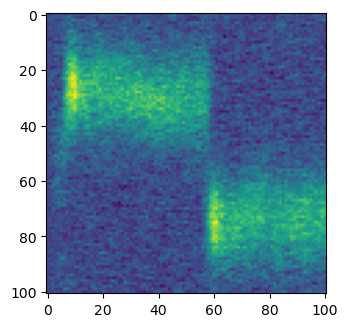

In [2]:


#=========================================================================================
# Helper function
#=========================================================================================

def angle_diff(theta1, theta2, mode='rad'):
    # Compute the angle difference between theta1 and theta2 on a circle
    angle_circle = 2*np.pi if mode == 'rad' else 360.
    diff = abs(theta1-theta2)
    return np.minimum(diff, angle_circle-diff)

#=========================================================================================
# Parameters
#=========================================================================================

modelparams = dict(
    N           = 101, # Number of neurons
    tau         = 1.,  # time constant (ms)
    k           = 10,  # constant for divisive normalization
    J           = 50,  # magnitude of recurrent interaction
    a           = 0.5, # range of recurrent interaction
    alpha       = 0.1, # input magnitude
    rho         = 1,   # neuron density
    sigma       = 0.1, # original parameter np.sqrt(0.1) seems too strong. Need checking
    dt          = 0.01, # Simulation time step (ms)
    record_dt   = 1,
    Ttotal      = 100
)

#=========================================================================================
# Model
#=========================================================================================

class Model(object):
    def __init__(self, modelparams):
        # Model parameters
        self.params = modelparams.copy()

    def run(self, seed=123):
        p = self.params

        # Set random seed
        np.random.seed(seed)

        # Number of time points
        NT = int(p['Ttotal']/p['dt'])

        # Number of clusters
        N = p['N']


        # Stimulus
        A = (1+np.sqrt(1-8*np.sqrt(2*np.pi)*p['a']*p['k']/p['J']**2/p['rho']))/\
            (2*np.sqrt(2*np.pi)*p['a']*p['k']*p['rho'])

        I_peak = p['alpha'] * (A*p['rho']*p['J']/np.sqrt(2))

        stim1 = 1./2*np.pi
        dtheta = angle_diff(stim1, np.arange(N)/N*2*np.pi, 'rad')
        Istim1  = I_peak*np.exp(-dtheta**2/4/p['a']**2)

        stim2 = 3./2*np.pi
        dtheta = angle_diff(stim2, np.arange(N)/N*2*np.pi, 'rad')
        Istim2  = I_peak*np.exp(-dtheta**2/4/p['a']**2)


        # Recurrent connection weight
        dc = 2*np.pi*np.minimum(np.arange(N),N-np.arange(N))/N
        J = (p['J']/np.sqrt(2*np.pi)*p['a'])*np.exp(-0.5*dc**2/p['a']**2)
        fJ = rfft(J) # Fourier transform

        # Initialization
        U = np.zeros(N)

        # Record
        n_record = int(p['record_dt']//p['dt'])
        self.U = list()
        self.t = list()

        # Loop over time points in a trial
        for i_t in range(NT):

            #---- Stimulus ------------------------------------------------------

            I_ext = 0.
            if 5<i_t*p['dt']<10:
                I_ext += Istim1

            if 55<i_t*p['dt']<60:
                I_ext += Istim2

            #---- Dynamical equations -------------------------------------------

            # Divisive normalization
            Usq = U**2
            gamma = Usq/(1+p['k']*2*np.pi/N*np.sum(Usq))


            # Recurrent connections

            fgamma = rfft(gamma)
            I_rec = irfft(fJ * fgamma, N) * (2*np.pi/N)

            # Update dynamical variables
            U = U + p['dt']*(-U + I_rec + I_ext)/p['tau'] +\
                np.sqrt(p['dt']/p['tau'])*p['sigma']*np.random.randn(N)

            #---- Record --------------------------------------------------------
            if np.mod(i_t,n_record) == 1:
                self.U.append(U)
                self.t.append(i_t*p['dt'])

        self.U = np.array(self.U)
        self.t = np.array(self.t)
        
if __name__ == '__main__':
    model = Model(modelparams)
    model.run()

    fig = plt.figure(figsize=(4,4))
    ax = fig.add_axes([0.2, 0.2, 0.7, 0.7])
    plt.imshow(model.U.T)
    plt.savefig('wu2008_continuousattractornetwork.pdf')
    plt.show()
